# Lecture 6: The Capital Asset Pricing Model, Its Tests, Critiques, and Extensions

## Investment Analysis

The Capital Asset Pricing Model, or CAPM, is one of the central models in modern finance. It is simple enough to be used in corporate finance, portfolio management, and performance evaluation, but deep enough to raise fundamental questions about equilibrium, risk sharing, market efficiency, and empirical testing.

The core CAPM claim is:

> In equilibrium, the expected return on an asset depends on its contribution to the risk of the market portfolio, not on its own standalone volatility.

That contribution is measured by beta:

$$
\beta_i = \frac{\operatorname{Cov}(R_i,R_M)}{\operatorname{Var}(R_M)}
$$

The expected-return beta relationship is:

$$
\mathbb{E}[R_i] = R_f + \beta_i\left(\mathbb{E}[R_M]-R_f\right)
$$

This lecture explains where this equation comes from, how it is used, why it is elegant, why it is hard to test, and why modern asset pricing has moved beyond the simplest version of the CAPM while still retaining its core logic.

# 1. Learning Objectives

By the end of this lecture, students should be able to:

1. State the assumptions of the Sharpe-Lintner-Mossin CAPM.
2. Explain why the market portfolio is efficient in equilibrium.
3. Explain why the capital allocation line becomes the capital market line.
4. Derive the expected return-beta relationship.
5. Interpret beta as systematic risk rather than total volatility.
6. Explain the mutual fund theorem and the role of index funds.
7. Explain why aggregate borrowing and lending must net to zero.
8. Define the market price of risk.
9. Plot and interpret the security market line.
10. Define alpha and explain why the CAPM predicts alpha should be zero.
11. Use the CAPM to estimate a firm hurdle rate for NPV calculations.
12. Explain Merton and Roll's results on efficient frontier portfolios and the zero-beta portfolio.
13. Explain Roll's critique.
14. Explain why labor income and non-traded assets matter.
15. Describe extensions: Black CAPM, ICAPM, CCAPM, liquidity CAPM, conditional CAPM, heterogeneous-beliefs models, asymmetric-information models, and behavioral/noise-trader models.
16. Understand the current empirical status of the CAPM.

# 2. Setup: Python Libraries

The code examples use simulated returns. Simulated data let us control the true beta, alpha, and factor structure, which makes the conceptual lessons easier to see.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(2027)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

Matplotlib is building the font cache; this may take a moment.


# 3. Historical Context

The CAPM was developed in the 1960s by William Sharpe, John Lintner, Jan Mossin, and others. It grew out of Harry Markowitz's mean-variance portfolio theory.

Markowitz showed that investors should evaluate portfolios by expected return, variance, and covariance. The CAPM asks what expected returns must look like if all investors use mean-variance logic and markets clear.

The model's appeal comes from its equilibrium simplicity:

- investors all hold combinations of the risk-free asset and the market portfolio;
- all risky assets are held in the market portfolio;
- expected returns are proportional to market beta;
- idiosyncratic volatility does not earn a risk premium;
- the required return on equity can be estimated from one beta and one market risk premium.

This is why the CAPM became central to investment analysis, corporate finance, regulatory finance, and performance evaluation.

# 4. Assumptions of the Basic CAPM

The standard Sharpe-Lintner version of the CAPM relies on strong assumptions:

1. Investors are mean-variance optimizers.
2. Investors have homogeneous expectations about expected returns, variances, and covariances.
3. Investors can borrow and lend at the same risk-free rate.
4. Markets are frictionless: no taxes, transaction costs, or short-selling constraints.
5. Assets are perfectly divisible and tradable.
6. Investors are price takers.
7. All investors share a single-period horizon.
8. All risky assets are publicly traded.
9. There is no asymmetric information.
10. All investors can hold the same market portfolio.

These assumptions are unrealistic, but they are analytically useful. They allow us to derive a sharp equilibrium prediction.

# 5. From Individual Optimization to Market Equilibrium

In the previous lectures, the investor's mean-variance problem led to the capital allocation line:

$$
\mathbb{E}[R_C] = R_f + \frac{\mathbb{E}[R_P]-R_f}{\sigma_P}\sigma_C
$$

where portfolio \(P\) is some risky portfolio.

The slope is the Sharpe ratio:

$$
S_P = \frac{\mathbb{E}[R_P]-R_f}{\sigma_P}
$$

If all investors agree about expected returns and covariances, then all investors agree about the tangency portfolio. They may choose different allocations between the risk-free asset and the tangency portfolio, but the risky portfolio itself is the same.

In equilibrium, that common tangency portfolio must be the market portfolio.

# 6. Why the Market Portfolio Must Be Efficient

Suppose all investors want to hold the same tangency portfolio of risky assets.

Market clearing requires that the aggregate demand for each risky asset equals its supply.

The total risky-asset portfolio held by all investors must therefore equal the total supply of risky assets.

That total supply is the market portfolio:

$$
M = \text{value-weighted portfolio of all risky assets}
$$

Therefore, in CAPM equilibrium:

$$
\text{Tangency portfolio} = \text{Market portfolio}
$$

Because the tangency portfolio is efficient, the market portfolio is efficient.

This is the equilibrium logic behind the CAPM.

# 7. Prices Adjust Until All Assets Are Held

What if an asset is not attractive enough to be held?

Its price must fall.

A lower price raises its expected return.

What if an asset is too attractive?

Investors demand more of it, pushing its price up.

A higher price lowers its expected return.

Prices adjust until all assets are willingly held in the market portfolio.

In equilibrium, every asset must offer the right expected return for its contribution to market risk.

# 8. The Mutual Fund Theorem

The CAPM implies a mutual fund theorem.

If investors share expectations and can borrow or lend at the risk-free rate, then every investor can hold just two funds:

1. the risk-free asset;
2. the market portfolio of risky assets.

Risk tolerance determines the allocation between the two funds.

More risk-averse investors hold more of the risk-free asset.

Less risk-averse investors hold more of the market portfolio and may borrow to lever it.

This theorem provides a conceptual foundation for broad index funds.

A low-cost index fund approximates the diversified market portfolio, at least within a given asset class.

# 9. Net Borrowing and Lending Must Be Zero

Some investors may want to lend at the risk-free rate.

Other investors may want to borrow at the risk-free rate.

But in aggregate, net borrowing and lending must sum to zero:

$$
\sum_i B_i = 0
$$

One investor's risk-free asset is another investor's risk-free liability.

In equilibrium, the risk-free rate adjusts so that desired aggregate lending equals desired aggregate borrowing.

This is why every investor can combine the same market portfolio with different risk-free positions, while the aggregate risky portfolio remains the market portfolio.

# 10. The Capital Allocation Line Becomes the Capital Market Line

For an individual investor, a line from the risk-free asset through any risky portfolio is a capital allocation line.

In CAPM equilibrium, the best risky portfolio is the market portfolio.

Therefore, the capital allocation line through the market portfolio is the capital market line:

$$
\mathbb{E}[R_C] = R_f + \frac{\mathbb{E}[R_M]-R_f}{\sigma_M}\sigma_C
$$

The slope is the market price of risk:

$$
\frac{\mathbb{E}[R_M]-R_f}{\sigma_M}
$$

It measures the expected excess return per unit of market volatility.

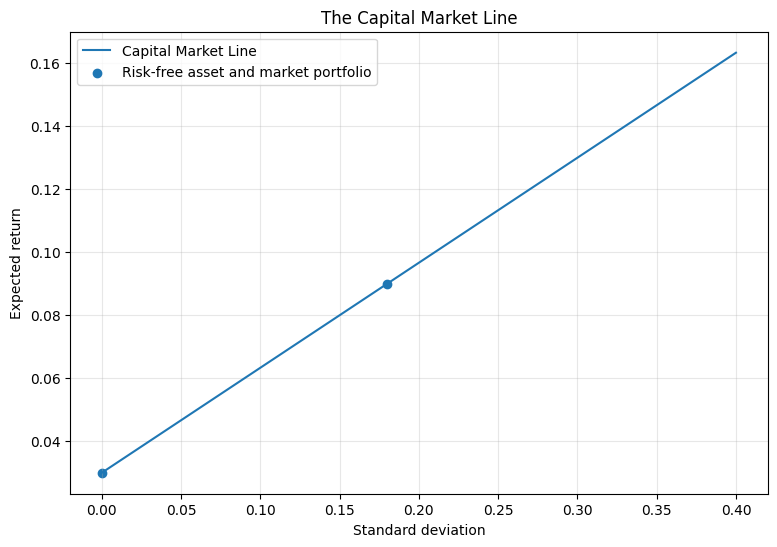

Market price of risk, using standard deviation units: 0.3333


In [2]:
# Capital market line demonstration

rf = 0.03
mu_m = 0.09
sigma_m = 0.18

sigma_grid = np.linspace(0, 0.40, 200)
mu_cml = rf + (mu_m - rf) / sigma_m * sigma_grid

plt.figure(figsize=(9,6))
plt.plot(sigma_grid, mu_cml, label="Capital Market Line")
plt.scatter([0, sigma_m], [rf, mu_m], label="Risk-free asset and market portfolio")
plt.xlabel("Standard deviation")
plt.ylabel("Expected return")
plt.title("The Capital Market Line")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Market price of risk, using standard deviation units: {(mu_m-rf)/sigma_m:.4f}")

# 11. The Covariance of One Stock with the Market Portfolio

The market portfolio is a value-weighted portfolio of all risky assets:

$$
R_M = \sum_{j=1}^N w_j R_j
$$

The covariance of stock \(i\) with the market is:

$$
\operatorname{Cov}(R_i,R_M)
=
\operatorname{Cov}\left(R_i,\sum_{j=1}^N w_jR_j\right)
$$

Using covariance linearity:

$$
\operatorname{Cov}(R_i,R_M)
=
\sum_{j=1}^N w_j\operatorname{Cov}(R_i,R_j)
$$

So a stock's market covariance is the weighted sum of its covariances with all assets in the market portfolio.

This is why beta is a portfolio concept. It measures how the asset contributes to the risk of the aggregate market portfolio.

In [3]:
# Demonstration: covariance with market is weighted sum of covariances with all stocks

weights = np.array([0.40, 0.30, 0.20, 0.10])
Sigma = np.array([
    [0.0400, 0.0180, 0.0120, 0.0060],
    [0.0180, 0.0625, 0.0200, 0.0100],
    [0.0120, 0.0200, 0.0900, 0.0140],
    [0.0060, 0.0100, 0.0140, 0.0300]
])

market_var = weights @ Sigma @ weights
cov_with_market = Sigma @ weights
beta = cov_with_market / market_var

pd.DataFrame({
    "Market Weight": weights,
    "Covariance with Market": cov_with_market,
    "Beta": beta
}, index=["Stock A", "Stock B", "Stock C", "Stock D"])

,Market Weight,Covariance with Market,Beta
Stock A,0.4000,0.0244,0.9311
Stock B,0.3000,0.0309,1.1811
Stock C,0.2000,0.0302,1.1525
Stock D,0.1000,0.0112,0.4274


# 12. Deriving the CAPM Expected Return-Beta Relationship

The market portfolio is efficient. For any asset \(i\), the relevant risk is the asset's marginal contribution to market portfolio risk.

The CAPM says that all assets must offer the same compensation per unit of contribution to market risk:

$$
\frac{\mathbb{E}[R_i]-R_f}{\operatorname{Cov}(R_i,R_M)}
=
\frac{\mathbb{E}[R_M]-R_f}{\operatorname{Var}(R_M)}
$$

Rearrange:

$$
\mathbb{E}[R_i]-R_f
=
\frac{\operatorname{Cov}(R_i,R_M)}{\operatorname{Var}(R_M)}
\left(\mathbb{E}[R_M]-R_f\right)
$$

Define beta:

$$
\beta_i = \frac{\operatorname{Cov}(R_i,R_M)}{\operatorname{Var}(R_M)}
$$

Then:

$$
\mathbb{E}[R_i]
=
R_f + \beta_i\left(\mathbb{E}[R_M]-R_f\right)
$$

This is the CAPM.

# 13. The Market Price of Risk

There are two related market prices of risk.

Using volatility units, the market price of risk is the Sharpe ratio of the market portfolio:

$$
\frac{\mathbb{E}[R_M]-R_f}{\sigma_M}
$$

Using covariance units, the market price of risk is:

$$
\lambda
=
\frac{\mathbb{E}[R_M]-R_f}{\operatorname{Var}(R_M)}
$$

Then:

$$
\mathbb{E}[R_i]-R_f
=
\lambda\operatorname{Cov}(R_i,R_M)
$$

This form emphasizes that expected excess return is compensation for covariance with the market, not for standalone volatility.

In [4]:
# CAPM expected returns from covariance risk

expected_market_excess = mu_m - rf
lambda_cov = expected_market_excess / market_var
expected_returns = rf + beta * expected_market_excess

pd.DataFrame({
    "Market Weight": weights,
    "Beta": beta,
    "Expected Return by CAPM": expected_returns,
    "Standalone Volatility": np.sqrt(np.diag(Sigma))
}, index=["Stock A", "Stock B", "Stock C", "Stock D"])

,Market Weight,Beta,Expected Return by CAPM,Standalone Volatility
Stock A,0.4000,0.9311,0.0859,0.2000
Stock B,0.3000,1.1811,0.1009,0.2500
Stock C,0.2000,1.1525,0.0991,0.3000
Stock D,0.1000,0.4274,0.0556,0.1732


# 14. Systematic Risk, Not Total Volatility

The CAPM does not say that expected return rises with total volatility.

It says expected return rises with beta.

A stock can have high standalone volatility but low beta if much of its volatility is idiosyncratic.

A stock can have moderate standalone volatility but high beta if its returns strongly covary with the market.

The reason is diversification. Investors can diversify idiosyncratic risk, so equilibrium expected returns do not compensate investors for bearing diversifiable risk.

In [5]:
# High volatility does not necessarily mean high CAPM expected return

example = pd.DataFrame({
    "Asset": ["High idiosyncratic-volatility stock", "High-beta cyclical stock"],
    "Beta": [0.50, 1.50],
    "Total Volatility": [0.60, 0.30]
})
example["CAPM Expected Return"] = rf + example["Beta"] * (mu_m-rf)
example

,Asset,Beta,Total Volatility,CAPM Expected Return
0,High idiosyncratic-volatility stock,0.5000,0.6000,0.0600
1,High-beta cyclical stock,1.5000,0.3000,0.1200


# 15. The Security Market Line

The security market line, or SML, plots expected return against beta.

The equation is:

$$
\mathbb{E}[R_i] = R_f + \beta_i(\mathbb{E}[R_M]-R_f)
$$

The intercept is the risk-free rate.

The slope is the market risk premium:

$$
\mathbb{E}[R_M]-R_f
$$

Assets above the SML have positive alpha.

Assets below the SML have negative alpha.

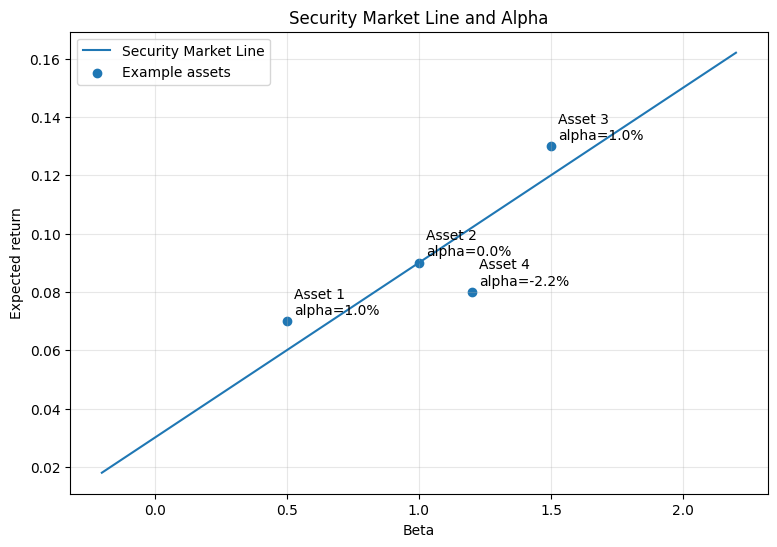

,Beta,Actual Expected Return,CAPM Required Return,Alpha
Asset 1,0.5000,0.0700,0.0600,0.0100
Asset 2,1.0000,0.0900,0.0900,0.0000
Asset 3,1.5000,0.1300,0.1200,0.0100
Asset 4,1.2000,0.0800,0.1020,-0.0220


In [6]:
# Plot the security market line and example securities

beta_grid = np.linspace(-0.2, 2.2, 200)
sml = rf + beta_grid * (mu_m-rf)

asset_betas = np.array([0.5, 1.0, 1.5, 1.2])
actual_expected_returns = np.array([0.07, 0.09, 0.13, 0.08])
capm_required = rf + asset_betas * (mu_m-rf)
alphas = actual_expected_returns - capm_required

plt.figure(figsize=(9,6))
plt.plot(beta_grid, sml, label="Security Market Line")
plt.scatter(asset_betas, actual_expected_returns, label="Example assets")
for i, (b, r, a) in enumerate(zip(asset_betas, actual_expected_returns, alphas)):
    plt.annotate(f"Asset {i+1}\nalpha={a:.1%}", (b, r), textcoords="offset points", xytext=(5,5))
plt.xlabel("Beta")
plt.ylabel("Expected return")
plt.title("Security Market Line and Alpha")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

pd.DataFrame({
    "Beta": asset_betas,
    "Actual Expected Return": actual_expected_returns,
    "CAPM Required Return": capm_required,
    "Alpha": alphas
}, index=["Asset 1", "Asset 2", "Asset 3", "Asset 4"])

# 16. Alpha in the CAPM

CAPM alpha is:

$$
\alpha_i
=
\mathbb{E}[R_i]
-
\left[R_f+\beta_i(\mathbb{E}[R_M]-R_f)\right]
$$

The CAPM predicts:

$$
\alpha_i=0
$$

for every asset.

Positive alpha means the asset offers more expected return than required for its beta.

Negative alpha means the asset offers less expected return than required for its beta.

In an efficient CAPM world, prices adjust until alphas disappear.

# 17. CAPM as a Hurdle Rate for Managers

Corporate managers use the CAPM to estimate the cost of equity:

$$
r_E = R_f + \beta_E(\mathbb{E}[R_M]-R_f)
$$

This required return is used as a hurdle rate in capital budgeting.

For a project with the same systematic risk as the firm's equity, the project should be accepted if:

$$
NPV = -I_0 + \sum_{t=1}^T \frac{\mathbb{E}[CF_t]}{(1+r_E)^t} > 0
$$

The economic logic is:

> A firm should accept projects whose expected cash flows compensate shareholders for the systematic risk they bear.

A project's hurdle rate should depend on the project's risk, not merely on the firm's existing average risk.

In [7]:
# CAPM hurdle rate and NPV example

rf_hurdle = 0.04
market_risk_premium = 0.055
project_beta = 1.30
cost_of_equity = rf_hurdle + project_beta * market_risk_premium

initial_investment = 100_000_000
cash_flows = np.array([18_000_000, 22_000_000, 27_000_000, 35_000_000, 45_000_000])
years = np.arange(1, len(cash_flows)+1)
pv_cash_flows = cash_flows / (1 + cost_of_equity)**years
npv = -initial_investment + pv_cash_flows.sum()

print(f"Project beta: {project_beta:.2f}")
print(f"CAPM cost of equity / hurdle rate: {cost_of_equity:.2%}")
print(f"PV of expected cash flows: ${pv_cash_flows.sum():,.0f}")
print(f"NPV: ${npv:,.0f}")

Project beta: 1.30
CAPM cost of equity / hurdle rate: 11.15%
PV of expected cash flows: $103,121,189
NPV: $3,121,189


# 18. Simulation: CAPM Returns, Estimated Beta, and Estimated Alpha

The CAPM is a statement about expected returns.

In real data, we estimate beta and alpha from realized returns:

$$
R_{i,t}-R_{f,t}=\alpha_i+\beta_i(R_{M,t}-R_{f,t})+\epsilon_{i,t}
$$

Even if the true alpha is zero, estimated alpha will usually not be exactly zero in a finite sample.

Estimated alpha and beta are ex post statistics.

In [8]:
# Simulate CAPM-consistent stock returns and estimate alpha/beta

T = 240
rf_monthly = 0.0025
market_excess_mean = 0.005
market_excess_sigma = 0.045

market_excess = np.random.normal(market_excess_mean, market_excess_sigma, T)
true_beta = 1.4
true_alpha = 0.0
resid_sigma = 0.06
resid = np.random.normal(0, resid_sigma, T)
stock_excess = true_alpha + true_beta * market_excess + resid

def ols(y, x):
    X = np.column_stack([np.ones(len(x)), x])
    b = np.linalg.inv(X.T @ X) @ X.T @ y
    fitted = X @ b
    e = y - fitted
    n, k = X.shape
    s2 = e @ e / (n-k)
    covb = s2 * np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(covb))
    tstats = b / se
    r2 = 1 - (e @ e) / ((y-y.mean()) @ (y-y.mean()))
    return b, se, tstats, r2, e

bhat, se, tstats, r2, ehat = ols(stock_excess, market_excess)

print(f"True alpha: {true_alpha:.4%} monthly")
print(f"Estimated alpha: {bhat[0]:.4%} monthly")
print(f"Alpha t-stat: {tstats[0]:.2f}")
print(f"True beta: {true_beta:.2f}")
print(f"Estimated beta: {bhat[1]:.2f}")
print(f"Beta t-stat: {tstats[1]:.2f}")
print(f"R-squared: {r2:.3f}")

True alpha: 0.0000% monthly
Estimated alpha: 0.1128% monthly
Alpha t-stat: 0.28
True beta: 1.40
Estimated beta: 1.32
Beta t-stat: 14.85
R-squared: 0.481


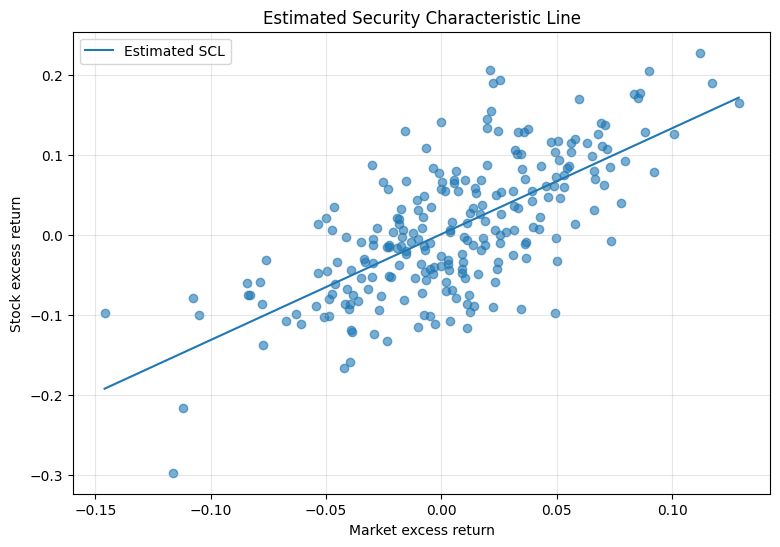

In [9]:
# Security characteristic line

xline = np.linspace(market_excess.min(), market_excess.max(), 100)
yline = bhat[0] + bhat[1]*xline

plt.figure(figsize=(9,6))
plt.scatter(market_excess, stock_excess, alpha=0.6)
plt.plot(xline, yline, label="Estimated SCL")
plt.xlabel("Market excess return")
plt.ylabel("Stock excess return")
plt.title("Estimated Security Characteristic Line")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 19. Merton and Roll: Efficient Frontier Portfolios and Linear Pricing

Important theoretical results by Merton and Roll clarify the geometry of efficient portfolios.

A key idea is that if a portfolio is mean-variance efficient, expected returns are linearly related to betas measured relative to that efficient portfolio.

This does not require the efficient portfolio to be the true market portfolio in the empirical data. Any mean-variance efficient portfolio can generate a beta pricing relation.

That fact is powerful, but it also creates an empirical problem:

> Finding a beta relation with respect to some portfolio does not necessarily prove that the true market portfolio is efficient.

Roll's critique builds directly on this point.

# 20. The Zero-Beta Portfolio

The Black zero-beta CAPM relaxes the assumption that investors can borrow and lend at a risk-free rate.

Instead of a risk-free asset, the model uses a zero-beta portfolio.

The zero-beta portfolio \(Z\) has zero covariance with the market portfolio:

$$
\beta_Z = 0
$$

The expected return-beta relationship becomes:

$$
\mathbb{E}[R_i]
=
\mathbb{E}[R_Z]
+
\beta_i\left(\mathbb{E}[R_M]-\mathbb{E}[R_Z]\right)
$$

The zero-beta portfolio takes the role of the intercept portfolio.

This version is useful because real-world borrowing rates often exceed lending rates, and a perfectly risk-free borrowing/lending asset may not exist for all investors.

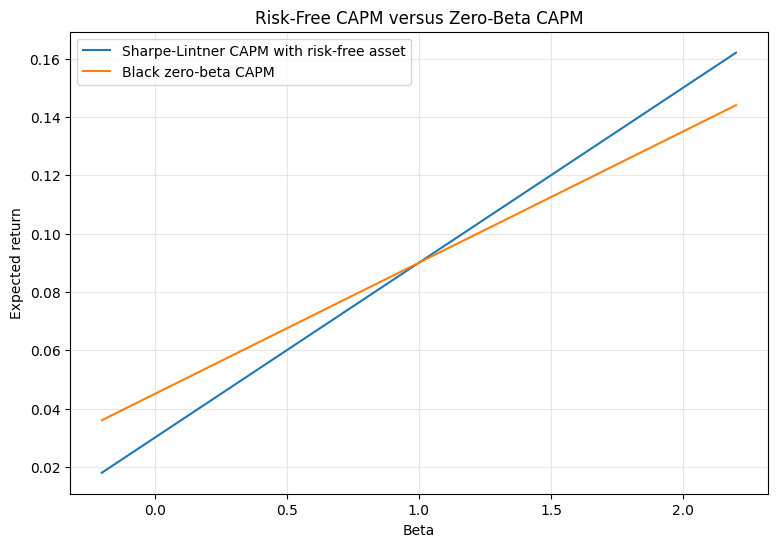

In [10]:
# Zero-beta CAPM line versus Sharpe-Lintner CAPM line

beta_grid = np.linspace(-0.2, 2.2, 200)
rz = 0.045
sml_rf = rf + beta_grid*(mu_m-rf)
sml_z = rz + beta_grid*(mu_m-rz)

plt.figure(figsize=(9,6))
plt.plot(beta_grid, sml_rf, label="Sharpe-Lintner CAPM with risk-free asset")
plt.plot(beta_grid, sml_z, label="Black zero-beta CAPM")
plt.xlabel("Beta")
plt.ylabel("Expected return")
plt.title("Risk-Free CAPM versus Zero-Beta CAPM")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 21. Roll's Critique

Roll's critique argues that the CAPM is not directly testable unless the true market portfolio is observed.

The theoretical market portfolio includes all assets:

- stocks,
- bonds,
- private businesses,
- real estate,
- human capital,
- durable goods,
- commodities,
- foreign assets,
- other non-traded claims.

Empirical tests usually use a stock-market index as a proxy.

If the proxy is inefficient, the test may reject the CAPM even if the true market portfolio is efficient.

If the proxy is efficient, beta pricing follows mechanically relative to that proxy.

Therefore, tests of the CAPM are often joint tests of:

1. the CAPM theory;
2. the chosen market proxy;
3. the statistical method;
4. the assumed information set.

# 22. Labor Income and Non-Traded Assets

The theoretical market portfolio includes human capital and other non-traded assets.

Labor income is especially important because for many households it is their largest asset.

If labor income is risky and correlated with the stock market, then the investor's optimal stock allocation changes.

A worker in a highly cyclical industry may rationally hold less equity than a worker with stable income.

Non-traded assets also affect equilibrium pricing because investors cannot freely trade all risks.

When important risks cannot be traded, the simple CAPM allocation result breaks down.

# 23. Merton's Intertemporal CAPM

The standard CAPM is a single-period model.

Merton's intertemporal CAPM, or ICAPM, extends the logic to a multiperiod setting.

In a multiperiod economy, investors care not only about next-period wealth, but also about changes in future investment opportunities.

State variables may include:

- interest rates,
- expected market returns,
- volatility,
- inflation,
- labor income risk,
- consumption opportunities.

Assets can be valuable because they hedge adverse changes in these state variables.

The expected return of an asset may depend on both:

1. covariance with the market portfolio;
2. covariance with state variables that forecast future investment opportunities.

The ICAPM can be written conceptually as:

$$
\mathbb{E}[R_i]-R_f
=
\beta_{iM}\lambda_M+
\beta_{i1}\lambda_1+
\cdots+
\beta_{ik}\lambda_k
$$

where the additional betas measure exposure to hedge portfolios associated with state variables.

This is a bridge from the CAPM to multifactor asset pricing.

# 24. Hedge Portfolios

A hedge portfolio is a portfolio designed to pay off when an economically important state variable moves adversely.

For example:

- a portfolio that performs well when interest rates fall may hedge recession risk;
- inflation-linked bonds may hedge inflation risk;
- long volatility strategies may hedge crash risk;
- defensive stocks may hedge consumption or labor-income risk for some investors.

In the ICAPM, investors may hold hedge portfolios in addition to the market portfolio.

This weakens the simple mutual fund theorem and replaces it with a multifund theorem.

# 25. The Consumption CAPM

The consumption CAPM, or CCAPM, starts from the stochastic discount factor:

$$
M_{t+1}=\beta\frac{u'(C_{t+1})}{u'(C_t)}
$$

Asset pricing requires:

$$
1=\mathbb{E}_t[M_{t+1}R_{i,t+1}]
$$

Expected returns are high when assets covary negatively with marginal utility, or equivalently, when they perform poorly in bad consumption states.

For power utility, the stochastic discount factor is related to consumption growth:

$$
M_{t+1}=\beta\left(\frac{C_{t+1}}{C_t}\right)^{-\gamma}
$$

The CCAPM replaces market beta with consumption beta.

The model is elegant, but empirically challenging because measured aggregate consumption is smooth and difficult to align with asset returns.

# 26. Transaction Costs, Liquidity, and Bid-Ask Spreads

The frictionless CAPM assumes costless trading.

Real markets have frictions:

- bid-ask spreads,
- brokerage commissions,
- price impact,
- funding constraints,
- margin requirements,
- short-sale constraints,
- taxes.

Less liquid assets may require higher expected returns.

The bid-ask spread is the difference between the price at which investors can buy and the price at which they can sell:

$$
\text{Spread} = Ask - Bid
$$

A proportional spread measure is:

$$
\frac{Ask-Bid}{(Ask+Bid)/2}
$$

Liquidity beta measures whether an asset performs poorly when marketwide liquidity deteriorates.

An asset with high liquidity beta may require a premium because it becomes hard to sell precisely when liquidity is most valuable.

In [11]:
# Bid-ask spread and liquidity beta illustration

bid = np.array([99.80, 49.50, 10.00])
ask = np.array([100.20, 50.50, 10.80])
mid = (bid+ask)/2
spread = ask-bid
prop_spread = spread/mid

pd.DataFrame({
    "Bid": bid,
    "Ask": ask,
    "Dollar Spread": spread,
    "Proportional Spread": prop_spread
}, index=["Liquid stock", "Moderate stock", "Illiquid stock"])

,Bid,Ask,Dollar Spread,Proportional Spread
Liquid stock,99.8000,100.2000,0.4000,0.0040
Moderate stock,49.5000,50.5000,1.0000,0.0200
Illiquid stock,10.0000,10.8000,0.8000,0.0769


In [12]:
# Simulate liquidity beta: stock returns respond to market returns and liquidity shocks

T = 180
mkt = np.random.normal(0.005, 0.045, T)
liq = np.random.normal(0.0, 0.030, T)  # negative values can mean liquidity deteriorates

# Stock performs badly when liquidity shock is negative: positive coefficient on liquidity shock
stock = 0.001 + 1.1*mkt + 0.8*liq + np.random.normal(0, 0.04, T)

X = np.column_stack([np.ones(T), mkt, liq])
b = np.linalg.inv(X.T@X)@X.T@stock
res = stock-X@b
s2 = res@res/(T-X.shape[1])
se = np.sqrt(np.diag(s2*np.linalg.inv(X.T@X)))
tstats=b/se

pd.DataFrame({
    "Coefficient": b,
    "Std Error": se,
    "t-stat": tstats
}, index=["Alpha", "Market beta", "Liquidity beta"])

,Coefficient,Std Error,t-stat
Alpha,-0.0028,0.0032,-0.8837
Market beta,1.1866,0.0737,16.1087
Liquidity beta,1.0607,0.1122,9.4516


# 27. Heterogeneous Beliefs and Asymmetric Information

The basic CAPM assumes homogeneous expectations.

In real markets, investors disagree.

They may differ because of:

- different information,
- different models,
- different interpretations,
- overconfidence,
- career concerns,
- institutional constraints.

Asymmetric information means some traders know more than others.

Information traders trade on signals.

Noise traders trade for liquidity, sentiment, or mistaken beliefs.

With heterogeneous beliefs and asymmetric information, prices may reflect risk, information, liquidity, and limits to arbitrage.

The clean CAPM relation can break down because investors no longer agree on the same expected returns and covariances.

# 28. Clientele Effects

Different investor clienteles may prefer different assets.

Examples:

- taxable investors may prefer low-dividend stocks;
- pension funds may prefer long-duration assets;
- banks may prefer assets favored by regulation;
- insurance companies may prefer assets that match liabilities;
- retail investors may prefer lottery-like payoffs;
- ESG-constrained investors may avoid some sectors.

Clientele effects can affect prices and expected returns because not all investors evaluate securities in the same way.

The CAPM's representative-investor logic abstracts from these differences.

# 29. Conditional CAPM and Time-Varying Alpha and Beta

The unconditional CAPM uses constant beta and a constant market risk premium:

$$
\mathbb{E}[R_i]-R_f = \beta_i(\mathbb{E}[R_M]-R_f)
$$

The conditional CAPM allows beta and expected market premiums to vary with information available at time \(t\):

$$
\mathbb{E}_t[R_{i,t+1}]-R_{f,t}
=
\beta_{i,t}\left(\mathbb{E}_t[R_{M,t+1}]-R_{f,t}\right)
$$

This matters because beta can vary with:

- leverage,
- volatility regimes,
- business cycle conditions,
- interest rates,
- firm fundamentals,
- operating leverage,
- market stress.

Alpha can also appear time-varying if the model omits changing risk exposures.

Unconditional beta estimate: 1.42
Average true beta: 1.09


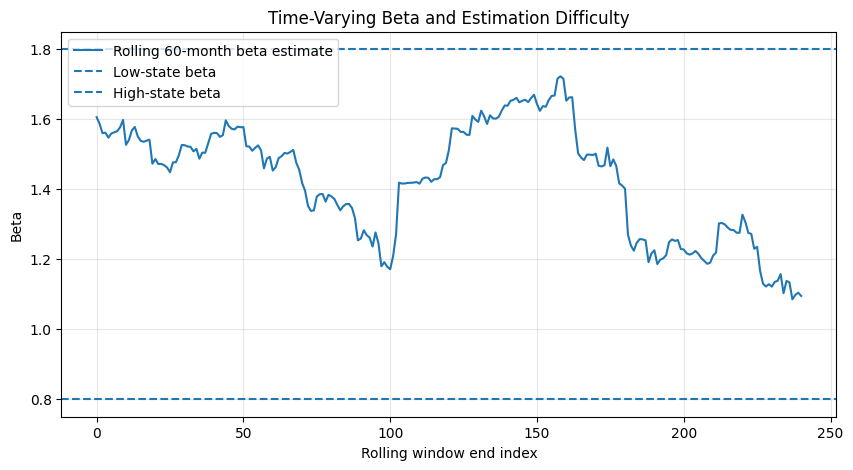

In [13]:
# Conditional beta simulation: beta rises in high-volatility states

T = 300
state = np.random.binomial(1, 0.30, T)  # 1 = high-risk state
mkt_cond = np.where(state==1,
                    np.random.normal(-0.004, 0.070, T),
                    np.random.normal(0.007, 0.035, T))
true_beta_t = np.where(state==1, 1.8, 0.8)
stock_cond = true_beta_t*mkt_cond + np.random.normal(0, 0.035, T)

# Estimate one unconditional beta
b_uncond, se_uncond, t_uncond, r2_uncond, _ = ols(stock_cond, mkt_cond)

# Rolling beta estimate
window = 60
rolling_beta = []
for start in range(T-window+1):
    y = stock_cond[start:start+window]
    x = mkt_cond[start:start+window]
    b, _, _, _, _ = ols(y, x)
    rolling_beta.append(b[1])
rolling_beta = np.array(rolling_beta)

print(f"Unconditional beta estimate: {b_uncond[1]:.2f}")
print(f"Average true beta: {true_beta_t.mean():.2f}")

plt.figure(figsize=(10,5))
plt.plot(rolling_beta, label="Rolling 60-month beta estimate")
plt.axhline(true_beta_t[state==0][0], linestyle="--", label="Low-state beta")
plt.axhline(true_beta_t[state==1][0], linestyle="--", label="High-state beta")
plt.xlabel("Rolling window end index")
plt.ylabel("Beta")
plt.title("Time-Varying Beta and Estimation Difficulty")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 30. Difficulties in Testing the CAPM

Testing the CAPM is difficult for several reasons.

## 1. The true market portfolio is unobservable

This is Roll's critique.

## 2. Expected returns are unobservable

Empirical tests use realized average returns as proxies for expected returns.

## 3. Betas are estimated with error

Beta estimates depend on sample period, frequency, benchmark, and regression specification.

## 4. Alphas and betas may be time-varying

A constant-beta regression may be misspecified.

## 5. Test assets matter

Tests using individual stocks can be noisy. Tests using portfolios can hide individual-stock variation.

## 6. Other characteristics appear to explain returns

Size, value, profitability, investment, momentum, liquidity, and quality variables often add explanatory power beyond market beta.

## 7. Data mining and model proliferation are concerns

Many proposed factors may not survive out-of-sample tests.

# 31. Current State of the Literature

The CAPM remains a foundational benchmark, but the strict one-factor empirical model has well-known limitations.

A careful modern summary is:

1. The CAPM is still important as a theoretical benchmark and practical cost-of-equity tool.
2. Market beta alone does not fully explain the cross-section of average returns.
3. Multifactor models such as Fama-French style models usually fit average returns better than the simple CAPM.
4. Conditional models recognize that betas and risk premia change over time.
5. Consumption-based and intertemporal models provide deeper microfoundations but are empirically challenging.
6. Liquidity, transaction costs, funding constraints, intermediary risk, and behavioral forces all complicate the simple CAPM world.
7. The central CAPM insight survives: only risks that cannot be diversified or hedged should command equilibrium compensation.

Thus, the CAPM is best understood as:

- a benchmark equilibrium model;
- a pedagogical foundation for systematic risk;
- a practical first-pass cost-of-equity model;
- not a complete empirical description of expected returns.

# 32. Summary of Key Formulas

## CAPM beta

$$
\beta_i = \frac{\operatorname{Cov}(R_i,R_M)}{\operatorname{Var}(R_M)}
$$

## CAPM expected return

$$
\mathbb{E}[R_i] = R_f + \beta_i(\mathbb{E}[R_M]-R_f)
$$

## Security market line

$$
\mathbb{E}[R_i] = R_f + \beta_i\text{MRP}
$$

## CAPM alpha

$$
\alpha_i = \mathbb{E}[R_i]-[R_f+\beta_i(\mathbb{E}[R_M]-R_f)]
$$

## Market price of covariance risk

$$
\lambda = \frac{\mathbb{E}[R_M]-R_f}{\operatorname{Var}(R_M)}
$$

## Covariance pricing form

$$
\mathbb{E}[R_i]-R_f = \lambda\operatorname{Cov}(R_i,R_M)
$$

## Covariance with market portfolio

$$
\operatorname{Cov}(R_i,R_M)=\sum_{j=1}^N w_j\operatorname{Cov}(R_i,R_j)
$$

## Capital market line

$$
\mathbb{E}[R_C] = R_f + \frac{\mathbb{E}[R_M]-R_f}{\sigma_M}\sigma_C
$$

## Black zero-beta CAPM

$$
\mathbb{E}[R_i]=\mathbb{E}[R_Z]+\beta_i(\mathbb{E}[R_M]-\mathbb{E}[R_Z])
$$

## Conditional CAPM

$$
\mathbb{E}_t[R_{i,t+1}]-R_{f,t}
=
\beta_{i,t}(\mathbb{E}_t[R_{M,t+1}]-R_{f,t})
$$

# 33. Final Takeaways

1. The CAPM derives asset expected returns from equilibrium risk sharing.

2. In CAPM equilibrium, the market portfolio is mean-variance efficient.

3. The individual capital allocation line becomes the capital market line.

4. The market portfolio is held because prices adjust until all assets are willingly held.

5. The mutual fund theorem says investors need only the risk-free asset and the market portfolio.

6. Net borrowing and lending must equal zero in aggregate.

7. Expected return depends on beta, not total volatility.

8. Beta measures covariance with the market portfolio divided by market variance.

9. The covariance of a stock with the market is the weighted sum of its covariances with all market assets.

10. The security market line gives the expected return-beta relationship.

11. Alpha is predicted to be zero in the CAPM.

12. Managers use the CAPM as a cost-of-equity and hurdle-rate model.

13. Roll's critique says the CAPM is hard to test because the true market portfolio is unobservable.

14. Labor income and non-traded assets complicate the simple market-portfolio logic.

15. ICAPM, CCAPM, liquidity models, conditional CAPM, and behavioral/information models extend the basic framework.

16. Empirically, the CAPM is an indispensable benchmark but not a complete model of expected returns.

# 34. References and Further Reading

- Black, Fischer. 1972. “Capital Market Equilibrium with Restricted Borrowing.” *Journal of Business*.
- Breeden, Douglas T. 1979. “An Intertemporal Asset Pricing Model with Stochastic Consumption and Investment Opportunities.” *Journal of Financial Economics*.
- Fama, Eugene F., and Kenneth R. French. 1992. “The Cross-Section of Expected Stock Returns.” *Journal of Finance*.
- Fama, Eugene F., and Kenneth R. French. 2004. “The Capital Asset Pricing Model: Theory and Evidence.” *Journal of Economic Perspectives*.
- Lintner, John. 1965. “The Valuation of Risk Assets and the Selection of Risky Investments in Stock Portfolios and Capital Budgets.” *Review of Economics and Statistics*.
- Markowitz, Harry. 1952. “Portfolio Selection.” *Journal of Finance*.
- Merton, Robert C. 1973. “An Intertemporal Capital Asset Pricing Model.” *Econometrica*.
- Mossin, Jan. 1966. “Equilibrium in a Capital Asset Market.” *Econometrica*.
- Roll, Richard. 1977. “A Critique of the Asset Pricing Theory's Tests.” *Journal of Financial Economics*.
- Ross, Stephen A. 1978. “The Current Status of the Capital Asset Pricing Model.” *Journal of Finance*.
- Sharpe, William F. 1964. “Capital Asset Prices: A Theory of Market Equilibrium under Conditions of Risk.” *Journal of Finance*.